In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import emoji

In [2]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comments.shape}")
print("\nMissing values per column (posts):")
print(posts.isna().sum())
print("\nMissing values per column (comments):")
print(comments.isna().sum())

print(f"\nDuplicate posts: {posts.duplicated(subset='msg_id').sum()}")
print(f"Duplicate comments: {comments.duplicated(subset='comment_id').sum()}")

Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Missing values per column (posts):
msg_id                0
date_utc              0
text                 39
views                 0
forwards              0
replies               0
has_media             0
media_type           28
sender_id             0
reply_to_msg_id    1943
num_comments          0
dtype: int64

Missing values per column (comments):
post_id           0
comment_id        0
date_utc          0
text           6840
sender_id     32160
dtype: int64

Duplicate posts: 0
Duplicate comments: 0


In [3]:
# ================= FILL MISSING VALUES =================
posts['views'] = posts['views'].fillna(0)
posts['forwards'] = posts['forwards'].fillna(0)
posts['replies'] = posts['replies'].fillna(0)
posts['media_type'] = posts['media_type'].fillna('Unknown')
posts['text'] = posts['text'].fillna('<media_only>')
posts['reply_to_msg_id'] = posts['reply_to_msg_id'].fillna('None')

comments['text'] = comments['text'].fillna('<deleted>')
comments['sender_id'] = comments['sender_id'].fillna('Unknown')


In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Remove URLs (links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Remove mentions and hashtags (optional - keep if needed for analysis)
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    # text = re.sub(r'#\w+', '', text)  # uncomment to remove hashtags
    
    # 3. Remove emojis OR convert them to text
    # Option A: Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Option B: Convert emojis to text (useful for sentiment)
    # text = emoji.demojize(text, delimiters=(":", ":"))
    
    # 4. Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\u1200-\u137F\s]', '', text)  # keeps Amharic and English
    
    # 5. Convert to lowercase (if English-heavy, but Amharic doesn't have case)
    text = text.lower()
    
    # 6. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning
posts['cleaned_text'] = posts['text'].apply(clean_text)
comments['cleaned_text'] = comments['text'].apply(clean_text)

In [ ]:
#========================= feature engineering =========================
# For posts
posts['text_length'] = posts['cleaned_text'].str.len()
posts['word_count'] = posts['cleaned_text'].str.split().str.len()
posts['has_question'] = posts['cleaned_text'].str.contains('\?').astype(int)

# For comments
comments['text_length'] = comments['cleaned_text'].str.len()
comments['word_count'] = comments['cleaned_text'].str.split().str.len()

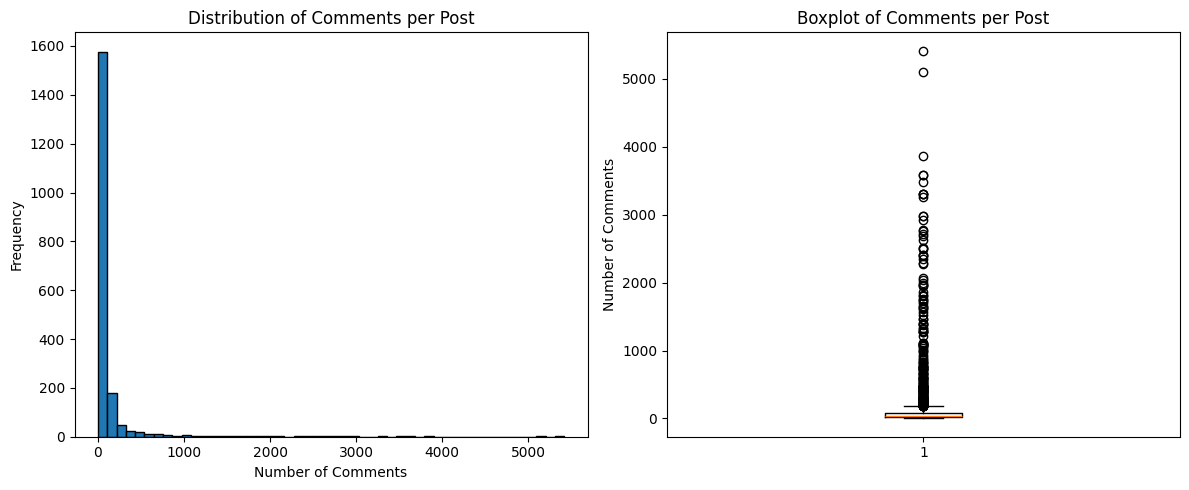

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(posts['num_comments'], bins=50, edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(posts['num_comments'])
plt.title('Boxplot of Comments per Post')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()
